## Exploratory Data Analysis 

### Goal

- Investigate top-paying roles and skills in the data science industry.
- Use Python to explore a real-live dataset on job postings.
- For job-seekers: use these insights to help find the best job opportunities.

### Final Deliverables:

- Create Jupyter Notebookss (showcasing core skills in Python).
- Create a summary page (via README.md) capturing your findings.
- Share this project via GitHub & Linkedln.

### Questions to Answer

1. What are the most demanded skills for the top 3 most popular data roles?
2. How are in-demand skills trending for Data Analysts?
3. How well do jobs and skills pay for Data Analysts?

### Original Exploration

12_Matplotlib_Format_Charts.ipynb

### Roles to Explore

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd. to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast. literal_eval(x) if pd.notna(x) else x)

c:\Users\USER\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Filter for US Data Analyst roles

In [3]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')]

df_plot = df_DA_US['job_location'].value_counts() .head(10). to_frame()

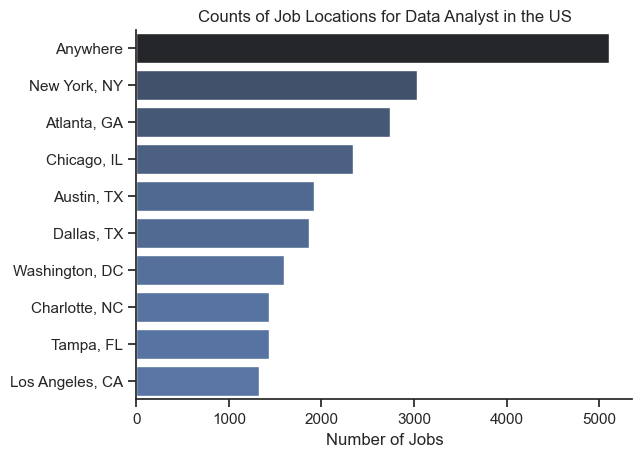

In [11]:
sns. set_theme(style='ticks')
sns. barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Job Locations for Data Analyst in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

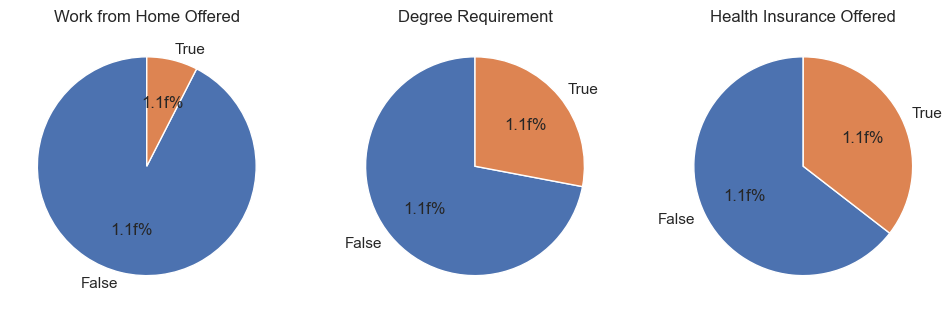

In [ ]:
# rewrite the above with a for loop
dict_column = {
'job_work_from_home': 'Work from Home Offered',
'job_no_degree_mention': 'Degree Requirement',
'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3)
fig.set_size_inches((12, 5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_US[column].value_counts(), labels=['False', 'True'], autopct='1.1f%%', startangle=90)
    ax[i].set_title(title)

# plt. suptitle('Benefit Analysis of Data Jobs', fontsize=16)
plt. show()

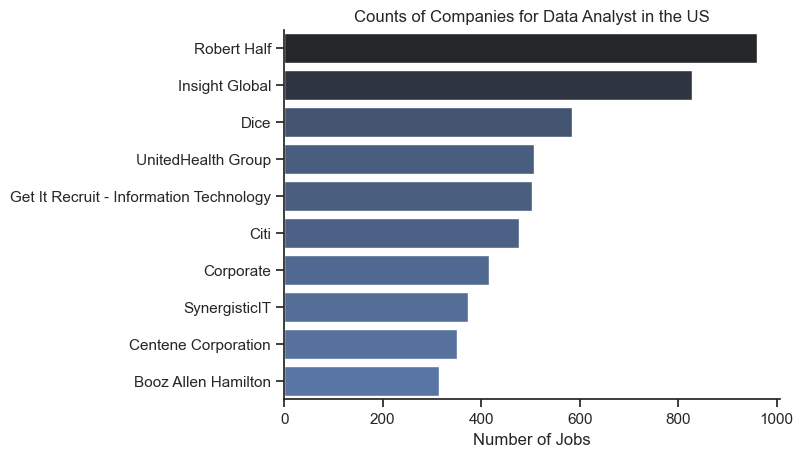

In [13]:
df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()

sns. set_theme(style='ticks')
sns. barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns. despine()
plt.title('Counts of Companies for Data Analyst in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt. show()